In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

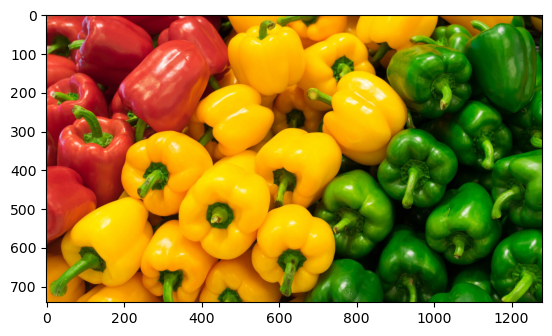

In [2]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/felfel-dolme.jpg")
plt.imshow(image[..., ::-1]);

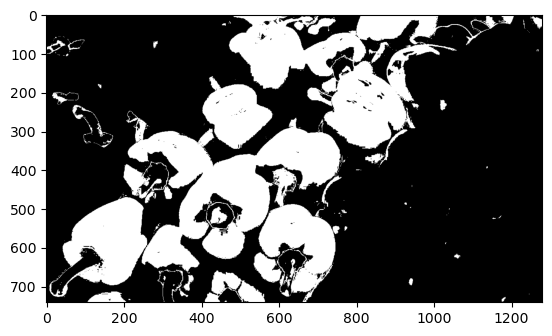

In [3]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower = np.array([20, 50, 50])
upper = np.array([35, 255, 255])

mask = cv2.inRange(hsv_image, lower, upper)

plt.imshow(mask, cmap='gray')

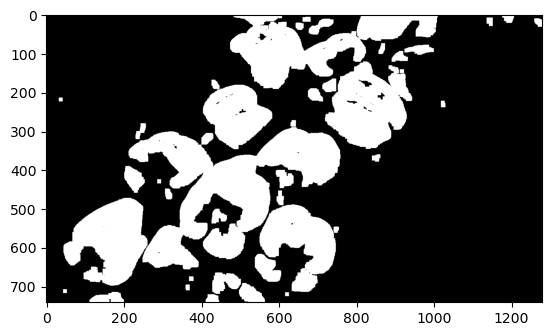

In [9]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel=kernel)

plt.imshow(opened, cmap='gray')

____

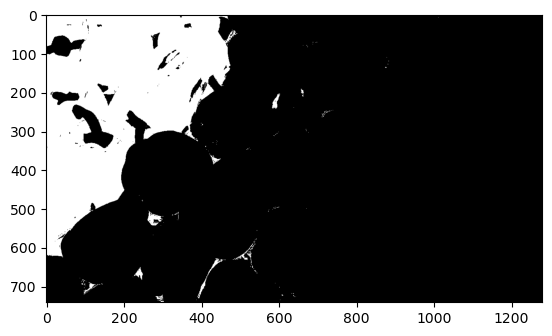

In [10]:
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])
mask0 = cv2.inRange(hsv_image, lower_red, upper_red)

lower_red = np.array([160, 50, 50])
upper_red = np.array([179, 255, 255])
mask1 = cv2.inRange(hsv_image, lower_red, upper_red)

mask = mask0 + mask1

plt.imshow(mask, cmap='gray')

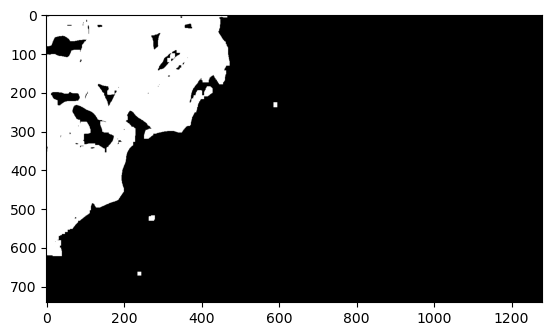

In [11]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel=kernel)

plt.imshow(opened, cmap='gray')

In [16]:
mask_hsv = cv2.merge([opened, opened, opened])
print(mask_hsv.shape)

(741, 1280, 3)


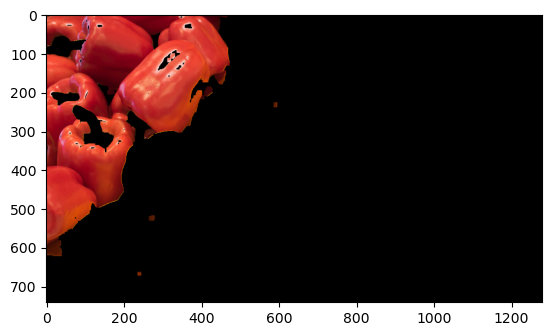

In [17]:
result = cv2.bitwise_and(image, mask_hsv)
plt.imshow(result[..., ::-1])

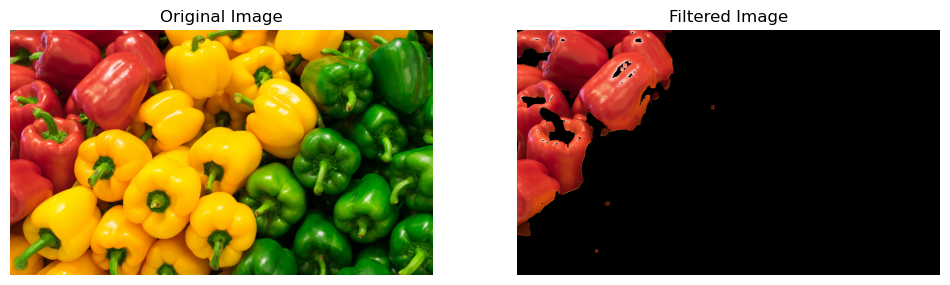

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[..., ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result[..., ::-1])
plt.title("Filtered Image")
plt.axis("off")

plt.show()